In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("Preprocessed_Dataset_For_Prediction.csv")
df = pd.get_dummies(df, drop_first=True)

In [3]:
df.head(3)

,Unnamed: 0,mrr_amount,seats,upgrade_flag,downgrade_flag,churn_flag,auto_renew_flag,usage_count,error_count,error_rate,resolution_time_hours,satisfaction_score,escalation_flag,no_feedback,no_ticket
0,0,3350.600000,34.200000,3,0,False,0.900000,514,27,0.052427,31.75,4.000000,0.0,0,0
1,1,1569.000000,15.333333,0,1,False,0.888889,602,31,0.051410,33.00,3.964163,0.0,1,0
2,2,678.333333,25.833333,1,0,False,0.833333,364,22,0.060274,32.00,3.000000,0.0,0,0


In [4]:
from sklearn.feature_selection import SequentialFeatureSelector

def backward_select_features(X, y, estimator, k_features, cv=5):
    sbs = SequentialFeatureSelector(estimator, n_features_to_select=k_features, direction='backward',cv=cv, n_jobs=-1)
    sbs.fit(X, y)
    selected_features = X.columns[sbs.get_support()]
    return X[selected_features]

In [5]:
X = df.drop("churn_flag", axis=1)
y = df["churn_flag"]

In [6]:
# Use Logistic Regression as base estimator for feature selection
X_selected = backward_select_features(X, y, LogisticRegression(max_iter=1000), k_features=5, cv=3)

In [7]:
# Split and scale
def split_scalar(indep_X, dep_Y):
    X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size=0.25, random_state=0)
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_scalar(X_selected, y)

In [8]:
def evaluate_model(classifier, X_train, y_train, X_test, y_test):
    classifier.fit(X_train, y_train)
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    y_pred = classifier.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return classifier, acc, report, cm

In [9]:
# Store accuracy for each model
accuracies = {}

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "SVM_Linear": SVC(kernel='linear'),
    "SVM_RBF": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier()
}

for name, model in models.items():
    clf, acc, report, cm = evaluate_model(model, X_train, y_train, X_test, y_test)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    # print(report)  # Optional

# Convert to DataFrame
result_df = pd.DataFrame([accuracies], index=["BackwardSelection"])
print("\nModel Accuracy Comparison:\n")
print(result_df)


Logistic Accuracy: 0.5680
SVM_Linear Accuracy: 0.5520
SVM_RBF Accuracy: 0.5520
KNN Accuracy: 0.5360
NaiveBayes Accuracy: 0.5600
DecisionTree Accuracy: 0.5360


C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RandomForest Accuracy: 0.5760

Model Accuracy Comparison:

                   Logistic  SVM_Linear  SVM_RBF    KNN  NaiveBayes  \
BackwardSelection     0.568       0.552    0.552  0.536        0.56   

                   DecisionTree  RandomForest  
BackwardSelection         0.536         0.576  


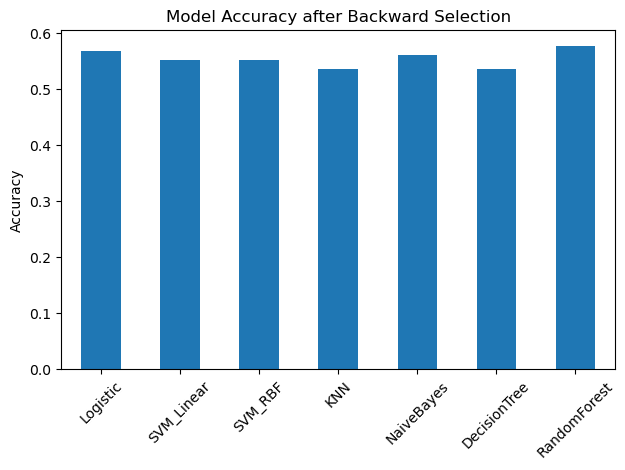

In [10]:
result_df.T.plot(kind='bar', legend=False)
plt.title("Model Accuracy after Backward Selection")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df.columns

Index(['Unnamed: 0', 'mrr_amount', 'seats', 'upgrade_flag', 'downgrade_flag',
       'churn_flag', 'auto_renew_flag', 'usage_count', 'error_count',
       'error_rate', 'resolution_time_hours', 'satisfaction_score',
       'escalation_flag', 'no_feedback', 'no_ticket'],
      dtype='object')

In [12]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
estimator = LogisticRegression(max_iter=5000,solver='saga')
sbs = SequentialFeatureSelector(estimator, n_features_to_select=5, direction='backward')
sbs.fit(X_scaled, y)

selected_feature_names = X.columns[sbs.get_support()]
print("Selected features:", list(selected_feature_names))

Selected features: ['Unnamed: 0', 'seats', 'usage_count', 'escalation_flag', 'no_feedback']
